# Laboratorio 6: Análisis de redes sociales en YouTube

CC3084 - Data Science, Semestre II 2026

Este notebook contiene el avance del laboratorio (ejercicios 1 al 4). Trabajamos con dos
conjuntos de datos de YouTube: uno con información de videos y canales, y otro con los
comentarios publicados en una selección de esos videos. La idea de este avance es dejar los
datos cargados, entendidos, limpios y con una primera exploración, más la construcción de la
red bipartita autor-video.


## 1. Carga, comprensión e integración de los datos


In [1]:
import pandas as pd
import numpy as np

pd.set_option('display.max_columns', 25)
pd.set_option('display.width', 140)

videos = pd.read_csv('data/youtube_videos.csv')
comments = pd.read_csv('data/youtube_comments.csv')

print('Videos:', videos.shape)
print('Comentarios:', comments.shape)


Videos: (293, 20)
Comentarios: (406, 17)


### 1.1 y 1.2 Unidad de observación y llaves primarias

En `youtube_videos.csv` cada fila es un video, y la llave primaria es `video_id`. Ese archivo
también trae `channel_id`, que es el identificador estable del canal (a diferencia de
`channel_name`, que puede repetirse o cambiar con el tiempo).

En `youtube_comments.csv` cada fila es un comentario principal (no incluye respuestas), y la
llave primaria es `comment_id`. La llave foránea hacia el otro archivo es `video_id`, y el
identificador del autor del comentario es `author_channel_id`, que es distinto del `channel_id`
del video (uno es quien comenta, el otro es quien publicó el video).


In [2]:
print('Video_id únicos en videos:', videos['video_id'].nunique(), 'de', len(videos), 'filas')
print('Comment_id únicos en comentarios:', comments['comment_id'].nunique(), 'de', len(comments), 'filas')
print()
print('Columnas relevantes de videos:')
print(videos[['video_id', 'channel_id', 'channel_name', 'category', 'view_count']].dtypes)
print()
print('Columnas relevantes de comentarios:')
print(comments[['comment_id', 'video_id', 'author_channel_id', 'author_name', 'reply_count']].dtypes)


Video_id únicos en videos: 293 de 293 filas
Comment_id únicos en comentarios: 406 de 406 filas

Columnas relevantes de videos:
video_id        object
channel_id      object
channel_name    object
category        object
view_count       int64
dtype: object

Columnas relevantes de comentarios:
comment_id           object
video_id             object
author_channel_id    object
author_name          object
reply_count           int64
dtype: object


### 1.3 Relación entre canal, video, autor, comentario, categoría y consulta

Un canal (`channel_id`) puede publicar varios videos, y cada video pertenece a un solo canal.
Cada video tiene una `category` asignada por YouTube y llegó al conjunto de datos a través de
una o varias consultas de búsqueda (`source_query`, `query_hits`). Un comentario pertenece a un
solo video, y fue escrito por un autor (`author_channel_id`), quien no tiene que ver con el
canal que publicó el video. Un mismo autor puede comentar en varios videos, y eso es justamente
lo que nos va a servir más adelante para armar la red autor-video: el autor y el video son los
dos tipos de nodo, y el hecho de comentar es lo que los conecta.


In [3]:
print('Canales distintos que publicaron los videos:', videos['channel_id'].nunique())
print('Autores distintos que comentaron:', comments['author_channel_id'].nunique())
print('Canales que recibieron comentarios:', comments['channel_id'].nunique())


Canales distintos que publicaron los videos: 97
Autores distintos que comentaron: 332
Canales que recibieron comentarios: 8


### 1.4 Integración por `video_id`


In [4]:
comments_full = comments.merge(
    videos,
    on='video_id',
    how='left',
    suffixes=('_comentario', '_video'),
    indicator=True,
)

print(comments_full['_merge'].value_counts())
print()
matched = (comments_full['_merge'] == 'both').sum()
print(f'{matched} de {len(comments)} comentarios pudieron asociarse con un video ({matched/len(comments):.1%}).')


_merge
both          406
left_only       0
right_only      0
Name: count, dtype: int64

406 de 406 comentarios pudieron asociarse con un video (100.0%).


Todos los comentarios lograron asociarse a un video, lo cual tiene sentido porque el archivo de
comentarios se construyó a partir de los videos del otro archivo. Sin embargo, notamos algo
importante para el resto del análisis: los 406 comentarios están repartidos en muy pocos videos.


In [5]:
videos_con_comentarios = comments['video_id'].nunique()
print(f'Videos con al menos un comentario: {videos_con_comentarios} de {len(videos)} videos totales.')
print(f'Es decir, solo el {videos_con_comentarios/len(videos):.1%} de los videos del conjunto tiene comentarios en este dataset.')


Videos con al menos un comentario: 19 de 293 videos totales.
Es decir, solo el 6.5% de los videos del conjunto tiene comentarios en este dataset.


Esto es una limitación importante que vamos a retomar más adelante: la red autor-video que
construyamos en la sección 4 solo va a tener información de esos videos con comentarios, no de
los 293 videos completos. No es que el resto de videos no tenga comentarios en YouTube, sino que
la recolección de comentarios se hizo solo para una parte de los videos.


## 2. Calidad, limpieza y preprocesamiento


### 2.1 Diagnóstico inicial de calidad


In [6]:
def diagnostico(df, nombre):
    print(f'--- {nombre} ---')
    print('Dimensiones:', df.shape)
    print()
    print('Valores nulos por columna:')
    print(df.isna().sum()[df.isna().sum() > 0])
    print()
    print('Filas duplicadas completas:', df.duplicated().sum())
    print()

diagnostico(videos, 'videos')
diagnostico(comments, 'comentarios')


--- videos ---
Dimensiones: (293, 20)

Valores nulos por columna:
published_time         13
view_count_text        13
description_snippet    25
description            26
dtype: int64

Filas duplicadas completas: 0

--- comentarios ---
Dimensiones: (406, 17)

Valores nulos por columna:
viewer_rating    406
dtype: int64

Filas duplicadas completas: 0



In [7]:
# Duplicados en las llaves primarias
print('video_id duplicados:', videos['video_id'].duplicated().sum())
print('comment_id duplicados:', comments['comment_id'].duplicated().sum())
print()

# Variables sin variabilidad (constantes)
print('Valores únicos de is_pinned:', comments['is_pinned'].unique())
print('Valores no nulos de viewer_rating:', comments['viewer_rating'].notna().sum(), 'de', len(comments))


video_id duplicados: 0
comment_id duplicados: 0

Valores únicos de is_pinned: [False]
Valores no nulos de viewer_rating: 0 de 406


`is_pinned` viene siempre en `False` en los 406 comentarios, así que no aporta nada para
diferenciar registros. `viewer_rating` está vacía en el 100% de los casos. Ninguna de las dos
sirve para el análisis.

También revisamos la consistencia entre identificadores y nombres visibles: si un mismo
`channel_id` siempre corresponde al mismo `channel_name`, y si `author_channel_id` siempre
corresponde al mismo `author_name`.


In [8]:
# Consistencia channel_id <-> channel_name (en videos)
nombres_por_canal = videos.groupby('channel_id')['channel_name'].nunique()
print('Canales con más de un channel_name distinto:', (nombres_por_canal > 1).sum())

# Consistencia author_channel_id <-> author_name (en comentarios)
nombres_por_autor = comments.groupby('author_channel_id')['author_name'].nunique()
print('Autores con más de un author_name distinto:', (nombres_por_autor > 1).sum())
print()
print(comments.groupby('author_channel_id')['author_name'].nunique().sort_values(ascending=False).head())


Canales con más de un channel_name distinto: 0
Autores con más de un author_name distinto: 0

author_channel_id
UC-HeUTT6_g-VoiWds2a4H-w    1
UC-Iul5tDYH_oiAMXQH-KaaQ    1
UC-QOpE7GOxlXcHZ8b7HbQKA    1
UC-fiZBS5Gp1eCJd9ucgWnCg    1
UC-hfX8J5JPJ-dfuakzegMLA    1
Name: author_name, dtype: int64


### 2.2 Variables que no vamos a usar o que requieren cuidado

- **`viewer_rating`**: vacía en todos los registros, la descartamos.
- **`is_pinned`**: constante en `False`, no aporta variabilidad, la descartamos del análisis
  (aunque la dejamos en el dataset original por transparencia).
- **`published_time`** (videos) y **`published_text`** (comentarios): son tiempos relativos
  ("hace 2 días", "hace 3 meses") que dependen del momento en que se recolectaron los datos, no
  son fechas exactas. Para videos ya tenemos `publish_date` en formato ISO, así que usamos esa.
  Para comentarios no existe una fecha exacta equivalente, así que cualquier análisis temporal de
  comentarios queda limitado a esas categorías relativas.
- **`dataset_sources`**: describe de qué archivo de recolección vino cada registro, es útil para
  auditoría pero no es una variable analítica en sí.
- **`description_snippet`**: es un fragmento recortado de `description`, lo tratamos como
  redundante y preferimos usar `description` completa cuando se necesite texto del video.
- **`video_title`** en el archivo de comentarios: es redundante porque se puede recuperar
  haciendo el join con `videos` por `video_id`.


### 2.3 Normalización de identificadores

No vamos a reemplazar los IDs por los nombres visibles en ningún momento del análisis
(`channel_id`, `video_id`, `comment_id` y `author_channel_id` siguen siendo las llaves). Lo único
que hacemos aquí es asegurarnos de que estén en formato texto limpio, sin espacios extra.


In [9]:
id_cols_videos = ['video_id', 'channel_id']
id_cols_comments = ['comment_id', 'video_id', 'channel_id', 'author_channel_id']

for col in id_cols_videos:
    videos[col] = videos[col].astype(str).str.strip()

for col in id_cols_comments:
    comments[col] = comments[col].astype(str).str.strip()

print('IDs normalizados (sin espacios extra).')


IDs normalizados (sin espacios extra).


### 2.4 Conversión de variables de conteo almacenadas como texto

`view_count_text` viene en el formato que muestra YouTube (por ejemplo `"2,390 vistas"`), y
`like_count_text` viene igual pero con bastantes valores vacíos (representados como espacios en
blanco cuando el comentario no tiene "me gusta" visibles). Escribimos una función para
convertirlas a número, quitando el texto ("vistas"), las comas de miles y espacios en blanco.


In [10]:
def texto_a_numero(valor):
    """Convierte conteos en formato de texto de YouTube (ej. '2,390 vistas') a entero."""
    if pd.isna(valor):
        return np.nan
    texto = str(valor).strip().lower()
    if texto == '' or texto == 'nan':
        return 0
    texto = texto.replace('vistas', '').replace('visitas', '').strip()
    texto = texto.replace(',', '').replace(' ', '')
    multiplicador = 1
    if texto.endswith('mil'):
        multiplicador = 1000
        texto = texto[:-3]
    elif texto.endswith('k'):
        multiplicador = 1000
        texto = texto[:-1]
    elif texto.endswith('m'):
        multiplicador = 1_000_000
        texto = texto[:-1]
    try:
        return int(float(texto) * multiplicador)
    except ValueError:
        return np.nan

# Validamos contra la columna view_count que ya viene calculada en el dataset
videos['view_count_calculado'] = videos['view_count_text'].apply(texto_a_numero)
con_texto = videos['view_count_text'].notna()
coinciden = (videos.loc[con_texto, 'view_count_calculado'] == videos.loc[con_texto, 'view_count']).sum()
print(f'view_count coincide con nuestro cálculo en {coinciden} de {con_texto.sum()} videos con view_count_text.')

diferencias = (videos.loc[con_texto, 'view_count'] - videos.loc[con_texto, 'view_count_calculado']).abs()
diferencias = diferencias[diferencias > 0]
print(f'En los {len(diferencias)} que no coinciden, la diferencia promedio es de {diferencias.mean():.1f} vistas.')

# like_count no viene precalculado, así que lo generamos nosotros
comments['like_count'] = comments['like_count_text'].apply(texto_a_numero)
print()
print('like_count generado, resumen:')
print(comments['like_count'].describe())


view_count coincide con nuestro cálculo en 227 de 280 videos con view_count_text.
En los 53 que no coinciden, la diferencia promedio es de 76.8 vistas.

like_count generado, resumen:
count    406.000000
mean       5.726601
std       30.661298
min        0.000000
25%        0.000000
50%        1.000000
75%        2.000000
max      405.000000
Name: like_count, dtype: float64


Nuestro cálculo a partir del texto coincide con `view_count` en la mayoría de los casos, pero no
en todos. Al revisar los que no coinciden vimos que la diferencia es siempre chica, unas cuantas
vistas de más o de menos, lo cual tiene sentido si `view_count` se recolectó en un momento un
poco distinto al de `view_count_text` y mientras tanto el conteo de YouTube siguió cambiando. No
es un error de nuestra función, es una consecuencia normal de raspar datos de una plataforma que
cambia en tiempo real. De todas formas confirma que la lógica de conversión funciona, así que la
usamos con confianza para generar `like_count`, que no venía calculado. De aquí en adelante
usamos `view_count` (numérico) y `like_count` (numérico) para cualquier análisis cuantitativo,
tal como recomienda el enunciado.


### 2.5 y 2.6 Texto original y texto limpio de los comentarios

Guardamos el texto tal cual está publicado en `texto_original`, porque lo vamos a necesitar
íntegro más adelante para el análisis de sentimiento (los modelos de sentimiento funcionan mejor
con signos de puntuación, mayúsculas y emojis originales). Para el análisis de frecuencias,
tópicos y nube de palabras construimos una versión aparte, `texto_limpio`.

Para `texto_limpio` decidimos:

- pasar todo a minúsculas.
- quitar URLs.
- separar hashtags y menciones en columnas propias (`hashtags`, `menciones`) y quitarlos del
  texto limpio para que no ensucien el conteo de palabras.
- quitar signos de puntuación y números.
- quitar stopwords en español (usamos la lista de NLTK).
- aplicar stemming en vez de lematización: no encontramos un lematizador de español confiable
  sin depender de internet, así que usamos `SnowballStemmer` de NLTK, que reduce las palabras a
  su raíz de forma automática. Documentamos esto como una limitación metodológica.
- convertir emojis a una descripción en texto (por ejemplo 😂 se convierte en algo como
  `cara_llorando_de_risa`) en vez de simplemente borrarlos, para no perder esa señal de
  sentimiento/tono.


In [11]:
import re
import string
import emoji
from nltk.corpus import stopwords
from nltk.stem import SnowballStemmer

stopwords_es = set(stopwords.words('spanish'))
stemmer = SnowballStemmer('spanish')

patron_url = re.compile(r'https?://\S+|www\.\S+')
patron_hashtag = re.compile(r'#\w+')
patron_mencion = re.compile(r'@\w+')

def extraer_hashtags(texto):
    return patron_hashtag.findall(str(texto))

def extraer_menciones(texto):
    return patron_mencion.findall(str(texto))

def limpiar_texto(texto):
    texto = str(texto)
    texto = emoji.demojize(texto, language='es')
    texto = texto.lower()
    texto = patron_url.sub(' ', texto)
    texto = patron_hashtag.sub(' ', texto)
    texto = patron_mencion.sub(' ', texto)
    texto = texto.translate(str.maketrans(string.punctuation, ' ' * len(string.punctuation)))
    texto = re.sub(r'\d+', ' ', texto)
    palabras = texto.split()
    palabras = [p for p in palabras if p not in stopwords_es and len(p) > 1]
    palabras = [stemmer.stem(p) for p in palabras]
    return ' '.join(palabras)

comments['texto_original'] = comments['text']
comments['hashtags'] = comments['text'].apply(extraer_hashtags)
comments['menciones'] = comments['text'].apply(extraer_menciones)
comments['texto_limpio'] = comments['text'].apply(limpiar_texto)

comments[['texto_original', 'texto_limpio']].head(8)


,texto_original,texto_limpio
0,Ese corrupto amigo de la vieja fiscal los teng...,corrupt amig viej fiscal verbos carcel
1,"Están jóvenes porque no buscan un trabajo, tu...",joven busc trabaj suert polic gust vand ir ves...
2,Me dejaron con ganas de demandar la ilegalidad...,dej gan demand ilegal reunion virtual maquil
3,Veremos a este mafioso de Mazariegos en la cár...,ver mafios mazarieg carcel buen tiemp sombr
4,eso es para que salga de USA por su propio pie...,salg usa propi pie aut deport
5,Imagine if they had to walk back home.,imagin if they had to walk back hom
6,buenísima investigacion :hand-purple-blue-peac...,buenisim investig hand purpl blu peac hand pur...
7,"Lleven su lonchera, sacrifiquense un poco. Y r...",llev loncher sacrifiquens reintevr diner rob


### 2.7 Efecto de la limpieza


In [12]:
vacios_antes = (comments['texto_original'].str.strip() == '').sum()
vacios_despues = (comments['texto_limpio'].str.strip() == '').sum()

dup_antes = comments['texto_original'].duplicated().sum()
dup_despues = comments['texto_limpio'].duplicated().sum()

print(f'Textos vacíos antes de limpiar: {vacios_antes}')
print(f'Textos vacíos después de limpiar: {vacios_despues}')
print()
print(f'Comentarios con texto original duplicado: {dup_antes}')
print(f'Comentarios con texto limpio duplicado: {dup_despues}')
print()

largo_antes = comments['texto_original'].str.len().mean()
largo_despues = comments['texto_limpio'].str.len().mean()
print(f'Longitud promedio del texto original: {largo_antes:.1f} caracteres')
print(f'Longitud promedio del texto limpio: {largo_despues:.1f} caracteres')


Textos vacíos antes de limpiar: 0
Textos vacíos después de limpiar: 1

Comentarios con texto original duplicado: 2
Comentarios con texto limpio duplicado: 4

Longitud promedio del texto original: 139.2 caracteres
Longitud promedio del texto limpio: 79.8 caracteres


Vemos que después de limpiar aparecen más comentarios vacíos y más duplicados que antes. Tiene
sentido: varios comentarios eran casi puro emoji, signos de puntuación o stopwords, y al quitar
todo eso quedan en blanco o se vuelven iguales a otros comentarios cortos (por ejemplo dos
comentarios que solo decían "jajaja" o puro emoji terminan como el mismo texto limpio vacío).
Para el análisis exploratorio de la siguiente sección vamos a tener en cuenta que un `texto_limpio`
vacío no significa que el comentario original estuviera vacío, sino que no le quedó contenido
después de quitar stopwords, puntuación y emojis.


## 3. Análisis exploratorio


### 3.1 Descripción general


In [13]:
print('Videos:', len(videos))
print('Canales que publicaron videos:', videos['channel_id'].nunique())
print('Comentarios:', len(comments))
print('Autores distintos que comentaron:', comments['author_channel_id'].nunique())


Videos: 293
Canales que publicaron videos: 97
Comentarios: 406
Autores distintos que comentaron: 332


Este análisis de comentarios y autores lo hicimos sobre los 19 videos que sí tienen comentarios,
los otros 274 videos estaban vacíos en este dataset y no entran en estas cuentas.


In [14]:
videos_por_canal = videos.groupby('channel_id').size().sort_values(ascending=False)
print('Videos por canal, resumen:')
print(videos_por_canal.describe())
print()
print('Canales con más videos publicados:')
top_canales_videos = videos_por_canal.head(5).rename('n_videos').reset_index().merge(
    videos[['channel_id', 'channel_name']].drop_duplicates(), on='channel_id'
)
print(top_canales_videos[['channel_name', 'n_videos']])


Videos por canal, resumen:
count    97.000000
mean      3.020619
std       5.141699
min       1.000000
25%       1.000000
50%       1.000000
75%       2.000000
max      32.000000
dtype: float64

Canales con más videos publicados:
                            channel_name  n_videos
0  Gobierno de la República de Guatemala        32
1             Municipalidad de Guatemala        27
2                                 Quorum        18
3                     PrensaLibreOficial        17
4              Ministerio de Gobernación        14


In [15]:
comentarios_por_video = comments.groupby('video_id').size().rename('n_comentarios')
autores_por_video = comments.groupby('video_id')['author_channel_id'].nunique().rename('n_autores')

resumen_videos_comentados = pd.concat([comentarios_por_video, autores_por_video], axis=1)
resumen_videos_comentados = resumen_videos_comentados.merge(
    videos[['video_id', 'title', 'channel_name', 'view_count']], on='video_id'
).sort_values('n_comentarios', ascending=False)

resumen_videos_comentados[['title', 'channel_name', 'n_comentarios', 'n_autores', 'view_count']]


,title,channel_name,n_comentarios,n_autores,view_count
14,Qué rico come tu diputado,Quorum,161,128,11775
12,La cooptación de Walter Mazariegos en la USAC,Quorum,50,49,10156
2,Inician los trabajos de recuperación del Puent...,Gobierno de la República de Guatemala,45,32,11670
13,Plan 2032 Ciudad de Guatemala,Municipalidad de Guatemala,25,25,304089
5,Conferencia de Prensa del Gobierno de Guatemal...,Gobierno de la República de Guatemala,25,19,3628
4,EE.UU. envía a mexicanos deportados a Guatemal...,Noticias Telemundo,25,18,14200
17,Arroz con pollo a la MONOPOLIO,Quorum,16,16,1954
0,Capturan a presuntos delincuentes disfrazados ...,Noti7,14,13,6692
15,Internet: escoger el menos malo,Quorum,12,10,717
11,Capturan a ladrón que había quedado grabado mi...,TN23 Guatemala,7,7,4616


In [16]:
print('Vistas (view_count):')
print(videos['view_count'].describe())
print()
print('Respuestas por comentario (reply_count):')
print(comments['reply_count'].describe())
print()
print('Me gusta por comentario (like_count):')
print(comments['like_count'].describe())


Vistas (view_count):
count    2.930000e+02
mean     6.043009e+04
std      5.157983e+05
min      2.000000e+00
25%      2.150000e+02
50%      1.175000e+03
75%      7.465000e+03
max      8.190449e+06
Name: view_count, dtype: float64

Respuestas por comentario (reply_count):
count    406.000000
mean       0.125616
std        0.580748
min        0.000000
25%        0.000000
50%        0.000000
75%        0.000000
max        7.000000
Name: reply_count, dtype: float64

Me gusta por comentario (like_count):
count    406.000000
mean       5.726601
std       30.661298
min        0.000000
25%        0.000000
50%        1.000000
75%        2.000000
max      405.000000
Name: like_count, dtype: float64


In [17]:
print('Categorías de los videos:')
print(videos['category'].value_counts())
print()
print('Consultas de búsqueda más frecuentes (source_query):')
print(videos['source_query'].value_counts().head(10))


Categorías de los videos:
category
News & Politics          138
People & Blogs            66
Entertainment             48
Education                 19
Travel & Events            8
Science & Technology       6
Nonprofits & Activism      3
Film & Animation           2
Comedy                     1
Sports                     1
Music                      1
Name: count, dtype: int64

Consultas de búsqueda más frecuentes (source_query):
source_query
Municipalidad de Guatemala                20
Gobierno de Guatemala                     18
@GobiernodelaRepublicadeGuatema           18
@GobiernodeGuatemala                      17
guatemala noticias                        16
Ministerio de Comunicaciones Guatemala    16
@MunicipalidaddeGuatemala-1551            16
Gobierno de la República de Guatemala     15
PMT Guatemala                             15
Conred Guatemala                          15
Name: count, dtype: int64


In [18]:
total_hashtags = comments['hashtags'].apply(len).sum()
print(f'Comentarios con al menos un hashtag: {(comments["hashtags"].apply(len) > 0).sum()} de {len(comments)}')
print(f'Total de hashtags encontrados: {total_hashtags}')
print(comments.loc[comments['hashtags'].apply(len) > 0, 'hashtags'].tolist())


Comentarios con al menos un hashtag: 1 de 406
Total de hashtags encontrados: 1
[['#IneptoBran']]


Casi nadie usa hashtags en los comentarios, solo aparece uno en los 406 comentarios. Esto tiene
sentido porque los hashtags son más una práctica del que publica el video que del que comenta, así
que no es un canal de información que vayamos a poder explotar mucho.


In [19]:
from collections import Counter

todas_las_palabras = ' '.join(comments['texto_limpio']).split()
frecuencia_palabras = Counter(todas_las_palabras)

print('Palabras más frecuentes (después de limpiar y quitar stopwords):')
for palabra, n in frecuencia_palabras.most_common(20):
    print(f'{palabra}: {n}')


Palabras más frecuentes (después de limpiar y quitar stopwords):
car: 87
si: 74
guatemal: 71
hac: 65
pais: 58
puebl: 57
trabaj: 56
diput: 51
pag: 44
buen: 40
com: 40
sol: 39
llor: 36
president: 35
diner: 34
man: 32
ris: 31
corrupt: 30
bander: 26
ser: 25


Al ver esta lista nos dimos cuenta de algo que no esperábamos: varias de las palabras más
frecuentes (`car`, `llor`, `ris`, `man`, `bander`) no son palabras que la gente haya escrito, son
pedazos de emojis. Cuando convertimos un emoji como 😂 a texto, `emoji.demojize` lo escribe como
`cara_llorando_de_risa`, y luego nuestra limpieza separa esas palabras por los guiones bajos y las
reduce a su raíz, entonces "cara", "llorando" y "risa" terminan contadas como si fueran tres
palabras normales del comentario. Nos pareció importante dejarlo documentado en vez de esconderlo,
porque cambia cómo hay que leer esta tabla: buena parte de lo más "frecuente" en los comentarios
en realidad son reacciones en emoji, no texto escrito por los usuarios. Palabras que sí son texto
real y aparecen bastante son `guatemal`, `puebl`, `trabaj`, `diput`, `pag` y `corrupt`, que ya dan
una idea del tono de los comentarios (bastante político y crítico hacia figuras públicas).


In [20]:
bigramas = []
for texto in comments['texto_limpio']:
    palabras = texto.split()
    bigramas.extend(zip(palabras, palabras[1:]))

frecuencia_bigramas = Counter(bigramas)
print('Bigramas más frecuentes:')
for bigrama, n in frecuencia_bigramas.most_common(15):
    print(f'{bigrama}: {n}')


Bigramas más frecuentes:
('car', 'llor'): 36
('llor', 'ris'): 29
('ris', 'car'): 22
('bander', 'guatemal'): 19
('man', 'aplaud'): 19
('cañon', 'confeti'): 15
('haci', 'arrib'): 15
('pulg', 'haci'): 14
('guatemal', 'bander'): 12
('bernard', 'areval'): 10
('president', 'bernard'): 9
('aplaud', 'man'): 9
('car', 'cabr'): 8
('car', 'boc'): 8
('boc', 'abiert'): 8


Los bigramas confirman lo mismo: varios de los más comunes son cadenas de emojis seguidos
(`cara-llorando`, `llorando-risa`, `manos-aplaudiendo`) más que frases reales. Entre los que sí
son texto real, `bandera-guatemala` y `presidente-bernardo` aparecen varias veces, lo que apunta a
comentarios sobre la situación política del país y menciones directas al presidente.


### 3.2 Concentración de la participación


In [21]:
comentarios_por_video_ord = comments.groupby('video_id').size().sort_values(ascending=False)
top3_videos = comentarios_por_video_ord.head(3).sum()
print(f'Los 3 videos con más comentarios concentran {top3_videos} de {len(comments)} comentarios ({top3_videos/len(comments):.1%}).')

comentarios_por_canal_ord = comments.groupby('channel_id').size().sort_values(ascending=False)
top3_canales = comentarios_por_canal_ord.head(3).sum()
print(f'Los 3 canales con más comentarios concentran {top3_canales} de {len(comments)} comentarios ({top3_canales/len(comments):.1%}).')


Los 3 videos con más comentarios concentran 256 de 406 comentarios (63.1%).
Los 3 canales con más comentarios concentran 351 de 406 comentarios (86.5%).


La participación está bastante concentrada. Con apenas 3 de los 19 videos comentados y 3 de los 8
canales que reciben comentarios ya se explica más de la mitad de todos los comentarios del
dataset. Un solo canal, Quorum, se lleva 256 de los 406 comentarios (más del 60%), a pesar de que
no es el canal que más videos publicó (eso lo tiene el canal del Gobierno de la República de
Guatemala, con 32 videos). O sea que la cantidad de contenido que publica un canal no
necesariamente predice cuánta conversación genera.


### 3.3 Popularidad vs. participación


In [22]:
comparacion = pd.concat([comentarios_por_video, videos.set_index('video_id')['view_count']], axis=1, join='inner')
comparacion.columns = ['n_comentarios', 'view_count']

correlacion_pearson = comparacion['view_count'].corr(comparacion['n_comentarios'])
correlacion_spearman = comparacion['view_count'].corr(comparacion['n_comentarios'], method='spearman')

print(f'Correlación (Pearson) entre vistas y número de comentarios: {correlacion_pearson:.2f}')
print(f'Correlación (Spearman, por rangos) entre vistas y número de comentarios: {correlacion_spearman:.2f}')
print()
print(comparacion.sort_values('view_count', ascending=False))


Correlación (Pearson) entre vistas y número de comentarios: 0.07
Correlación (Spearman, por rangos) entre vistas y número de comentarios: 0.81

             n_comentarios  view_count
video_id                              
lj983NWyAQY             25      304089
OkXlHx0hx-8             25       14200
n8iP75gIpmw            161       11775
6W4u8sGEnGM             45       11670
j43HgwYFKfk             50       10156
06mFNPU0aB8             14        6692
b_Hkrkl3adA              7        5469
is3Mk5oC19g              7        4616
PjmxCj-a9Hg             25        3628
yLZS3JiEBg8             16        1954
UhL9y3KUl8E              1        1755
X_FAIef8qlE              1        1140
TT4qJ5FXHYE              4        1075
ndAZjHqzzT8             12         717
JkpVO1hx2f8              3         673
3Nfp9h5avBI              2         573
WIUZtitfLRw              6         422
s0eco-BofOs              1         220
zweosulrwA8              1          52


Encontramos algo curioso aquí. La correlación normal (Pearson) sale casi en
cero, pero la correlación por rangos (Spearman) sale bastante alta, 0.81. Eso pasa porque hay un
video que es un caso muy extremo: tiene más de 300 mil vistas, muchísimas más que el resto, pero
"solo" 25 comentarios, una cantidad normal comparada con los otros videos. Ese único video
distorsiona por completo la correlación normal. Cuando en vez de mirar los números crudos miramos
el orden (cuál tiene más vistas que cuál, cuál tiene más comentarios que cuál), sí aparece una
relación bastante consistente entre popularidad y participación. La lectura que le damos es que
más vistas sí tienden a venir con más comentarios, pero no de forma proporcional ni lineal, y un
solo video viral puede tener muchísimo alcance sin que eso se traduzca en una conversación
igual de grande. Esto también hay que tomarlo con cuidado porque solo tenemos 19 videos con
comentarios para comparar, es una muestra chica para sacar conclusiones fuertes.


### 3.4 Visualizaciones


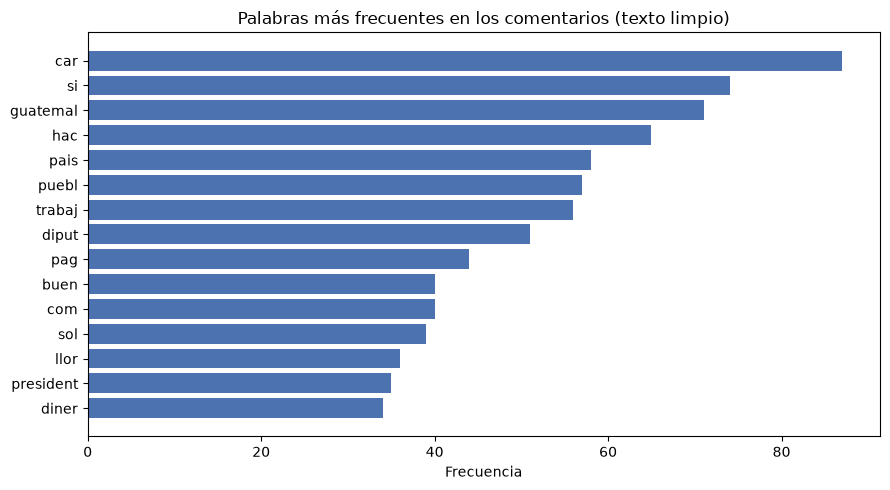

In [23]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 5))
palabras_top = frecuencia_palabras.most_common(15)
etiquetas = [p[0] for p in palabras_top]
valores = [p[1] for p in palabras_top]

ax.barh(etiquetas[::-1], valores[::-1], color='#4C72B0')
ax.set_xlabel('Frecuencia')
ax.set_title('Palabras más frecuentes en los comentarios (texto limpio)')
plt.tight_layout()
plt.show()


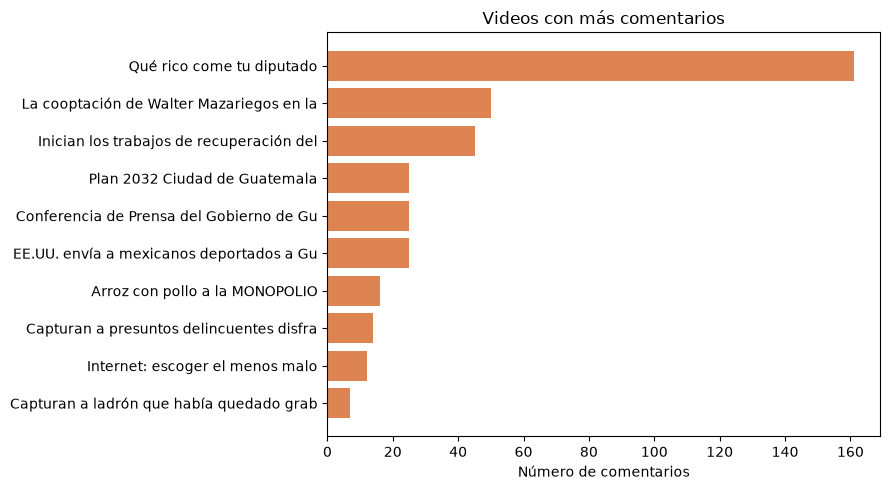

In [24]:
fig, ax = plt.subplots(figsize=(9, 5))
top_videos_grafica = resumen_videos_comentados.head(10)
ax.barh(top_videos_grafica['title'].str[:40][::-1], top_videos_grafica['n_comentarios'][::-1], color='#DD8452')
ax.set_xlabel('Número de comentarios')
ax.set_title('Videos con más comentarios')
plt.tight_layout()
plt.show()


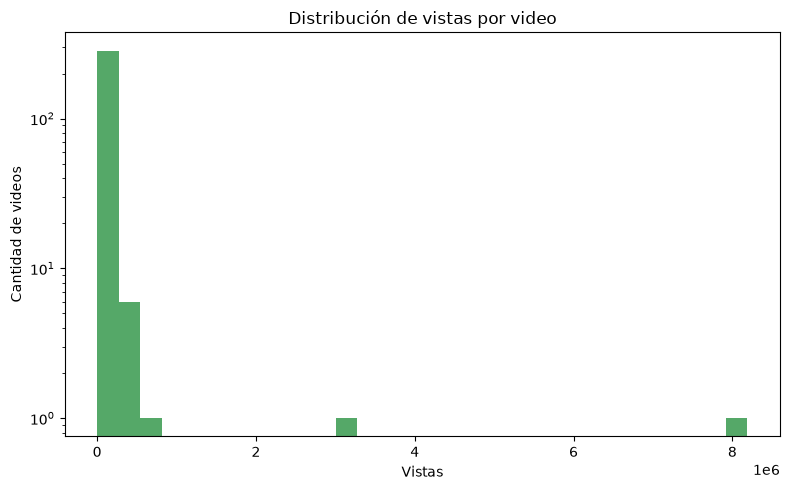

Usamos escala logarítmica en el eje Y porque hay muchísimos videos con pocas vistas
y muy pocos videos con vistas altísimas, así que en escala normal casi no se ven las barras chicas.


In [25]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(videos['view_count'], bins=30, color='#55A868')
ax.set_xlabel('Vistas')
ax.set_ylabel('Cantidad de videos')
ax.set_title('Distribución de vistas por video')
ax.set_yscale('log')
plt.tight_layout()
plt.show()

print('Usamos escala logarítmica en el eje Y porque hay muchísimos videos con pocas vistas')
print('y muy pocos videos con vistas altísimas, así que en escala normal casi no se ven las barras chicas.')


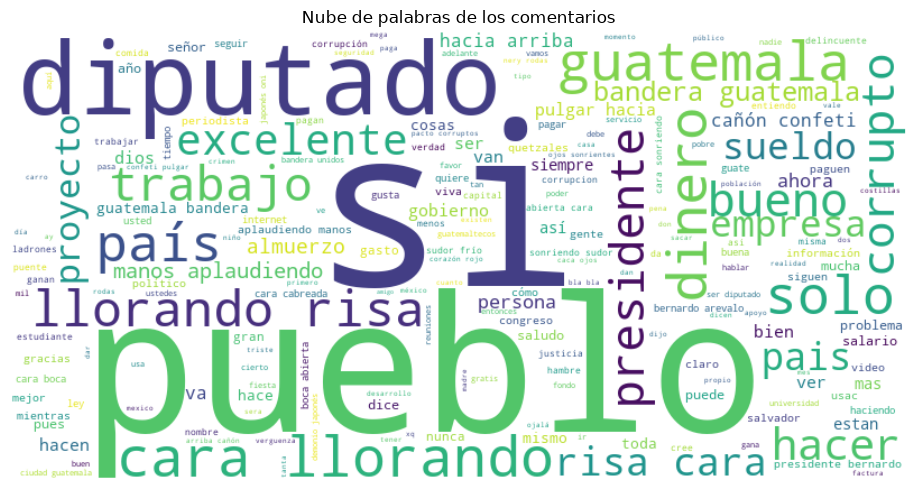

In [26]:
from wordcloud import WordCloud

# para la nube de palabras usamos las palabras limpias sin reducir a su raíz,
# porque las raíces del stemmer (ej. 'corrupt', 'diput') se leen raro en una nube
import re as _re
import string as _string

def limpiar_para_nube(texto):
    texto = str(texto)
    texto = emoji.demojize(texto, language='es')
    texto = texto.lower()
    texto = patron_url.sub(' ', texto)
    texto = patron_hashtag.sub(' ', texto)
    texto = patron_mencion.sub(' ', texto)
    texto = texto.translate(str.maketrans(_string.punctuation, ' ' * len(_string.punctuation)))
    texto = _re.sub(r'\d+', ' ', texto)
    palabras = [p for p in texto.split() if p not in stopwords_es and len(p) > 1]
    return ' '.join(palabras)

texto_para_nube = ' '.join(comments['text'].apply(limpiar_para_nube))

nube = WordCloud(width=800, height=400, background_color='white', colormap='viridis').generate(texto_para_nube)
fig, ax = plt.subplots(figsize=(10, 5))
ax.imshow(nube, interpolation='bilinear')
ax.axis('off')
ax.set_title('Nube de palabras de los comentarios')
plt.tight_layout()
plt.show()


Como dijimos en la sección 2, la nube de palabras la dejamos solo como complemento visual, no como
el análisis principal, porque no muestra bien las cantidades exactas ni deja comparar valores con
precisión. Para eso usamos las gráficas de barras de arriba.


### 3.5 Preguntas

**¿Qué videos y canales concentran la mayor participación observada?**

Un solo video de Quorum tiene 161 de los 406 comentarios. A nivel de canal, Quorum se lleva el 63%
de todos los comentarios con solo 18 videos, mientras que el canal del Gobierno, que publicó casi
el doble de videos, recibe muchos menos. Todo está bastante concentrado en pocos actores.

**¿Existen audiencias compartidas entre videos, canales o temas?**

Un poco. 9 de los 332 autores comentaron en más de un video, casi siempre en videos de temas
parecidos (política, corrupción).

**¿Qué autores funcionan como puentes entre contenidos que de otra forma permanecerían
separados?**

Por ahora, esos mismos 9 autores que comentan en varios videos. Dos de ellos comentaron en 3
videos distintos.  

**¿Qué temas y sentimientos caracterizan a las principales comunidades de participación?**

Todavía no corremos el análisis de sentimiento, pero ya se nota un tono
bastante crítico hacia políticos: palabras como "diputados", "corruptos" y "presidente" salen
seguido. El resto de temas frecuentes son dinero, trabajo y el país en general.

**¿La visibilidad medida mediante visualizaciones coincide con la participación observada?**

Coincide, pero no de forma exacta. Los videos con más vistas suelen tener más comentarios, salvo
por un video que se volvió viral y tuvo muchísimas vistas sin un salto igual de grande en
comentarios.

**¿Qué conclusiones están limitadas por el procedimiento de recolección y la cobertura de los
datos?**

La más importante: solo 19 de los 293 videos tienen comentarios en este dataset, así que todo lo
que decimos de comentarios y autores es solo de esos 19, no de la colección completa. Tampoco
sabemos si el resto de videos de verdad no tiene comentarios o simplemente no se recolectaron.


### 3.6 Preguntas adicionales


**¿El canal que más videos publicó es también el que recibe más comentarios?**


In [27]:
print('Canal con más videos publicados:', videos_por_canal.idxmax(), '->', videos_por_canal.max(), 'videos')
print('Canal con más comentarios recibidos:', comentarios_por_canal_ord.idxmax(), '->', comentarios_por_canal_ord.max(), 'comentarios')


Canal con más videos publicados: UC-ZtFBHzgkYFh7whZkuR_Ag -> 32 videos
Canal con más comentarios recibidos: UCE4rsXcgDb6e1-a9iTbWzfg -> 256 comentarios


No. El Gobierno publicó más videos (32), pero Quorum recibió más comentarios con solo 18. Parece
que importa más el tema o el estilo del contenido que la cantidad que se publica.


**¿Los comentarios con más "me gusta" tienden a ser comentarios más largos?**


In [28]:
comments['largo_texto'] = comments['text'].str.len()
correlacion_likes_largo = comments['like_count'].corr(comments['largo_texto'])
print(f'Correlación entre like_count y largo del comentario: {correlacion_likes_largo:.2f}')


Correlación entre like_count y largo del comentario: -0.03


Casi no hay relación. Un comentario corto puede tener tantos "me gusta" como uno largo.


**¿Qué proporción de los comentarios incluye al menos un emoji?**


In [29]:
comments['tiene_emoji'] = comments['text'].apply(lambda t: len(emoji.emoji_list(str(t))) > 0)
proporcion_emoji = comments['tiene_emoji'].mean()
print(f'{comments["tiene_emoji"].sum()} de {len(comments)} comentarios tienen al menos un emoji ({proporcion_emoji:.1%}).')


61 de 406 comentarios tienen al menos un emoji (15.0%).


Un 15%. No es la mayoría, pero fue suficiente para meterse en nuestro conteo de palabras
frecuentes, como vimos en el punto 3.1.


## 4. Construcción de la red bipartita autor-video


### 4.1 y 4.2 Construcción de la red

Vamos a armar una red bipartita: un tipo de nodo son los autores (`author_channel_id`) y el otro
son los videos (`video_id`). Ponemos una arista entre un autor y un video cuando ese autor comentó
en ese video, y el peso de la arista es cuántos comentarios escribió ahí. Como son puros
comentarios principales, no hay dirección que tenga sentido marcar, por eso la red es no dirigida.


In [30]:
import networkx as nx

pares_autor_video = comments.groupby(['author_channel_id', 'video_id']).size().reset_index(name='peso')
print('Pares autor-video distintos (aristas):', len(pares_autor_video))
pares_autor_video.head()


Pares autor-video distintos (aristas): 343


,author_channel_id,video_id,peso
0,UC-HeUTT6_g-VoiWds2a4H-w,6W4u8sGEnGM,1
1,UC-Iul5tDYH_oiAMXQH-KaaQ,6W4u8sGEnGM,1
2,UC-QOpE7GOxlXcHZ8b7HbQKA,OkXlHx0hx-8,2
3,UC-fiZBS5Gp1eCJd9ucgWnCg,j43HgwYFKfk,1
4,UC-hfX8J5JPJ-dfuakzegMLA,n8iP75gIpmw,1


In [31]:
G = nx.Graph()

for autor in pares_autor_video['author_channel_id'].unique():
    G.add_node(autor, tipo='autor')

for video_id in pares_autor_video['video_id'].unique():
    fila_video = videos.loc[videos['video_id'] == video_id].iloc[0]
    G.add_node(video_id, tipo='video', titulo=fila_video['title'], canal=fila_video['channel_name'])

for _, fila in pares_autor_video.iterrows():
    G.add_edge(fila['author_channel_id'], fila['video_id'], peso=fila['peso'])

print('Es bipartita:', nx.is_bipartite(G))
print('Nodos:', G.number_of_nodes())
print('Aristas:', G.number_of_edges())


Es bipartita: True
Nodos: 351
Aristas: 343


In [32]:
nodos_autor = [n for n, d in G.nodes(data=True) if d['tipo'] == 'autor']
nodos_video = [n for n, d in G.nodes(data=True) if d['tipo'] == 'video']
print('Nodos autor:', len(nodos_autor))
print('Nodos video:', len(nodos_video))


Nodos autor: 332
Nodos video: 19


Todos los autores del dataset terminan como nodo porque por definición cada uno escribió al menos
un comentario. Del lado de los videos solo entran los 19 que tienen comentarios, los otros 274 no
tienen ninguna arista posible en esta red.


### 4.3 Tabla de nodos y tabla de aristas


In [33]:
filas_nodos = []
for nodo, datos in G.nodes(data=True):
    fila = {'id': nodo, 'tipo': datos['tipo']}
    if datos['tipo'] == 'video':
        fila['titulo'] = datos.get('titulo')
        fila['canal'] = datos.get('canal')
    fila['grado'] = G.degree(nodo)
    filas_nodos.append(fila)

tabla_nodos = pd.DataFrame(filas_nodos)
print('Tabla de nodos:', tabla_nodos.shape)
tabla_nodos.sort_values('grado', ascending=False).head(10)


Tabla de nodos: (351, 5)


,id,tipo,grado,titulo,canal
335,n8iP75gIpmw,video,128,Qué rico come tu diputado,Quorum
334,j43HgwYFKfk,video,49,La cooptación de Walter Mazariegos en la USAC,Quorum
332,6W4u8sGEnGM,video,32,Inician los trabajos de recuperación del Puent...,Gobierno de la República de Guatemala
337,lj983NWyAQY,video,25,Plan 2032 Ciudad de Guatemala,Municipalidad de Guatemala
338,PjmxCj-a9Hg,video,19,Conferencia de Prensa del Gobierno de Guatemal...,Gobierno de la República de Guatemala
333,OkXlHx0hx-8,video,18,EE.UU. envía a mexicanos deportados a Guatemal...,Noticias Telemundo
343,yLZS3JiEBg8,video,16,Arroz con pollo a la MONOPOLIO,Quorum
339,06mFNPU0aB8,video,13,Capturan a presuntos delincuentes disfrazados ...,Noti7
341,ndAZjHqzzT8,video,10,Internet: escoger el menos malo,Quorum
336,b_Hkrkl3adA,video,7,Bloqueos en Guatemala este 31 de agosto por al...,PrensaLibreOficial


In [34]:
tabla_aristas = nx.to_pandas_edgelist(G, source='autor', target='video')
print('Tabla de aristas:', tabla_aristas.shape)
tabla_aristas.sort_values('peso', ascending=False).head(10)


Tabla de aristas: (343, 3)


,autor,video,peso
331,UCyJhqmMbsvjpoarBBStA2kg,6W4u8sGEnGM,6
244,UCi2KiZq63sRq8Mfbcp-MelQ,OkXlHx0hx-8,6
165,UCV3fr-YOixFKCZBbJP1-X4w,6W4u8sGEnGM,5
33,UC5H8ASmMC9WrURmzeB4ySog,n8iP75gIpmw,5
57,UC9vMq1YF-e7C-VO0SHkbUTA,n8iP75gIpmw,4
120,UCNIeXbV_mEwpa412h1aqUWw,PjmxCj-a9Hg,3
46,UC72gBAtyb_VXQlYDcFrh6oQ,n8iP75gIpmw,3
85,UCFjudnPLoaSL1BaRuLahyHg,n8iP75gIpmw,3
226,UCg3eIfd7BrsLEqS0BLkftHA,PjmxCj-a9Hg,3
234,UCh5ESQvtzyHDhCA7XyekCFA,n8iP75gIpmw,3


La mayoría de las aristas tienen peso 1, o sea que casi todos los autores comentaron una sola vez
en el video donde aparecen. Los pesos más altos (5 y 6) son de un par de autores que comentaron
varias veces en el mismo video.


### 4.4 Visualización de la red


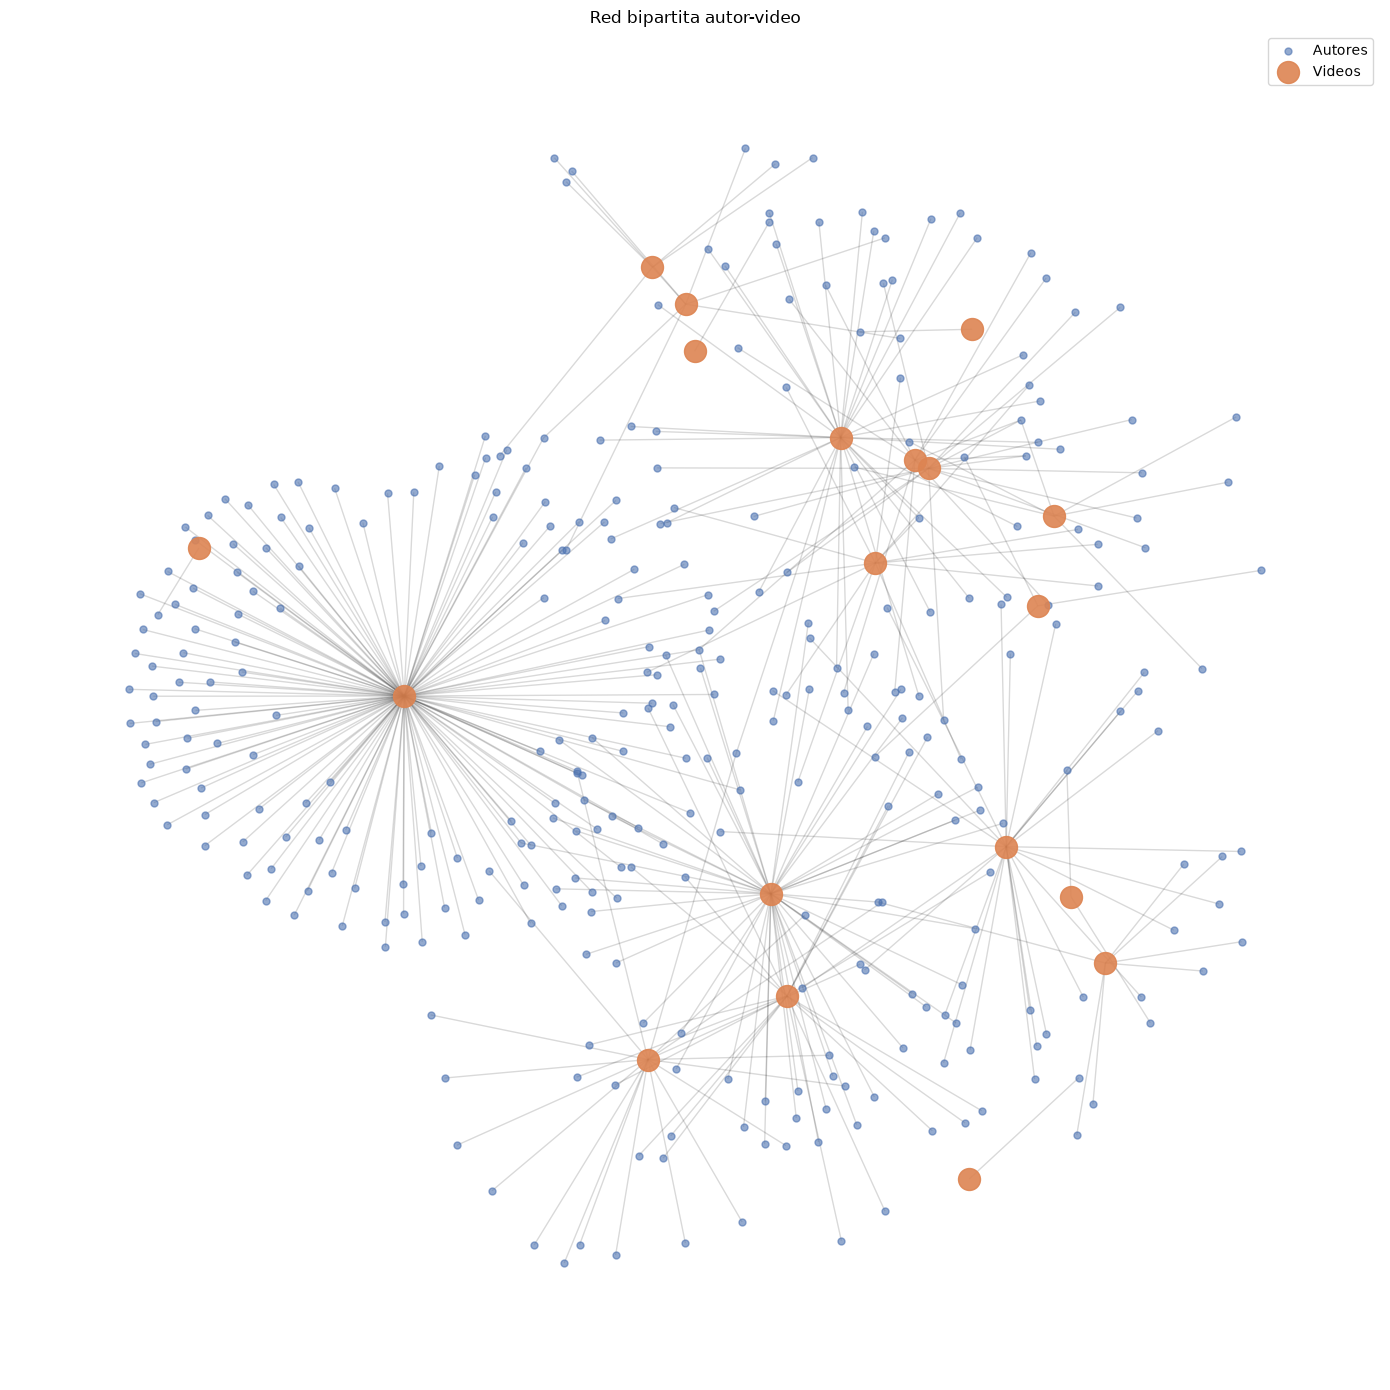

In [35]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(14, 14))
pos = nx.spring_layout(G, k=0.25, seed=42)

nx.draw_networkx_nodes(G, pos, nodelist=nodos_autor, node_color='#4C72B0', node_size=25, alpha=0.6, ax=ax, label='Autores')
nx.draw_networkx_nodes(G, pos, nodelist=nodos_video, node_color='#DD8452', node_size=250, alpha=0.9, ax=ax, label='Videos')
nx.draw_networkx_edges(G, pos, alpha=0.15, ax=ax)

ax.set_title('Red bipartita autor-video')
ax.legend(scatterpoints=1)
ax.axis('off')
plt.tight_layout()
plt.show()


Se nota bastante bien la estructura: los 19 videos (puntos naranjas, más grandes) están rodeados
de sus propios autores (puntos azules chiquitos), casi como estrellas. Los pocos autores que
comentaron en más de un video son los que aparecen conectando a dos de esas estrellas entre sí, el
resto queda pegado a un solo video.


### 4.5 Qué significa una arista (y qué no)

Una arista acá solo dice que un autor escribió al menos un comentario en ese video, nada más. No
significa que ese autor haya hablado con alguien, ni que le haya gustado el video, ni que tenga
ninguna relación con otros autores que también comentaron ahí. Dos autores conectados al mismo
video pudieron haber comentado en momentos completamente distintos y nunca haberse enterado el uno
del otro.

Esto conecta con algo que ya decia el enunciado del laboratorio: `reply_count` nos dice cuántas
respuestas recibió un comentario, pero no quién las escribió, así que no podemos usar esa columna
para armar aristas entre usuarios. La única relación que sí podemos afirmar con los datos que
tenemos es "este autor comentó en este video", y es justo eso lo que representa cada arista de
esta red.
